# Practical 4: Text Clustering and Topic Modeling
### Instructor: Dr. Maryam Movahedifar

<div style="display: flex; justify-content: space-between; align-items: center;">
  <span style="display: flex; align-items: center;">
    <b>Applied Text Mining - University of Bremen - Data Science Center</b>
  </span>
  <div style="display: flex; align-items: center; margin-left: auto;">
    <img src="Uni_Logo.png" alt="Uni Logo" style="width: 100px; margin-right: 10px;">
    <img src="DSC_Logo.png" alt="DSC Logo" style="width: 150px;">
  </div>
</div>

In this practical, we are going to apply different clustering algorithms and a topic modeling approach on sport news articles and cluster them into different groups.

Today we will use the following libraries. Take care to have them installed!

In [1]:
!pip install -q --upgrade pip setuptools wheel && pip install -q scikit-learn numpy gensim spacy nltk

In [2]:
from sklearn.datasets import load_files
import pandas as pd
import numpy as np

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

from sklearn.cluster import MiniBatchKMeans
from sklearn.cluster import AgglomerativeClustering
from scipy.cluster.hierarchy import dendrogram

from sklearn import metrics

from sklearn.decomposition import NMF
from sklearn.decomposition import LatentDirichletAllocation

# for reproducibility
random_state = 321

In [3]:
#%%capture

#!unzip ~/Text-Mining/data/bbcsport-fulltext.zip -d ~/Text-Mining/Answers

In [4]:
data = load_files('bbcsport-fulltext/bbcsport', encoding="utf-8", decode_error="replace", random_state=random_state)
df = pd.DataFrame(list(zip(data['data'], data['target'])), columns=['text', 'label'])
df.head()

,text,label
0,"Scotland v Italy (Sat)\n\nMurrayfield, Edinbur...",3
1,Wales silent on Grand Slam talk\n\nRhys Willia...,3
2,Arsenal 1-1 Sheff Utd\n\nAndy Gray's 90th-minu...,2
3,Cole refuses to blame van Persie\n\nAshley Col...,2
4,Van Nistelrooy hungry for return\n\nManchester...,2


In [5]:
labels, counts = np.unique(df['label'], return_counts=True)
print(dict(zip(data.target_names, counts)))

{'athletics': np.int64(101), 'cricket': np.int64(124), 'football': np.int64(265), 'rugby': np.int64(147), 'tennis': np.int64(100)}


2. **For text clustering and topic modeling, we will ignore the outcome variable (labels) but we will use them while evaluating models. Create a copied dataframe removing the outcome variable.**

In [6]:
bbcsport_text = pd.DataFrame(df['text'])
bbcsport_text.head()

,text
0,"Scotland v Italy (Sat)\n\nMurrayfield, Edinbur..."
1,Wales silent on Grand Slam talk\n\nRhys Willia...
2,Arsenal 1-1 Sheff Utd\n\nAndy Gray's 90th-minu...
3,Cole refuses to blame van Persie\n\nAshley Col...
4,Van Nistelrooy hungry for return\n\nManchester...


3. **Apply the following pre-processing steps and convert the data to a document-term matrix with term frequencies:**

- Convert to lowercase
- Remove stopwords
- Remove numbers
- Extract uni- and bi-grams
- Remove terms that occur in less than 2 documents
- Remove one-letter terms, e.g. 'a', or 's'


In [7]:
tfidf_vectorizer = TfidfVectorizer(stop_words='english',
                                   lowercase=True,
                                   min_df=2,
                                   ngram_range=(1,2),
                                   token_pattern=r'(?u)\b[A-Za-z][A-Za-z]+\b')
tfidf_vectorizer.fit(df.text.values)
tfidf_matrix = tfidf_vectorizer.transform(df.text.values)
tfidf_matrix.shape

(737, 21604)

In [8]:
# You can check the vocabulary of your vectorizer with the following line
tfidf_vectorizer.vocabulary_

{'scotland': 16588,
 'italy': 9554,
 'sat': 16416,
 'murrayfield': 12483,
 'edinburgh': 5500,
 'saturday': 16420,
 'february': 6375,
 'gmt': 7592,
 'live': 10930,
 'website': 20649,
 'victory': 20246,
 'azzurri': 1162,
 'rome': 15819,
 'year': 21407,
 'saw': 16453,
 'end': 5635,
 'campaign': 2428,
 'pressure': 14463,
 'coach': 3334,
 'matt': 11818,
 'williams': 20857,
 'seeks': 16838,
 'nations': 12557,
 'eighth': 5541,
 'attempt': 990,
 'lost': 11181,
 'opening': 13151,
 'games': 7288,
 'home': 8678,
 'ireland': 9450,
 'wales': 20390,
 'travel': 19657,
 'high': 8536,
 'hopes': 8748,
 'john': 9743,
 'kirwan': 10230,
 'warned': 20519,
 'errors': 5894,
 'blighted': 1816,
 'loss': 11173,
 'risk': 15689,
 'suffering': 18370,
 'successive': 18351,
 'defeat': 4554,
 'taught': 18702,
 'level': 10734,
 'make': 11412,
 'mistakes': 12256,
 'said': 16105,
 'error': 5893,
 'come': 3435,
 'price': 14500,
 'aggressive': 313,
 'minutes': 12165,
 'calm': 2377,
 'situation': 17385,
 'display': 5042,
 '

## K-Means clustering
4. **Use the MiniBatchKMeans function from the sklearn package, and a K-Means clustering algorithm with 5 clusters.**

In [9]:
n_clusters = 5
cls = MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, n_init = 3)
cls.fit(tfidf_matrix)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",321
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",3


In [10]:
print(cls)

MiniBatchKMeans(n_clusters=5, n_init=3, random_state=321)


5. **What are the top terms in each cluster?**

In [11]:
print("Top terms per cluster:")

order_centroids = cls.cluster_centers_.argsort()[:, ::-1]
terms = tfidf_vectorizer.get_feature_names_out()
for i in range(n_clusters):
    print("Cluster %d:" % i, end='')
    for ind in order_centroids[i, :10]:
        print(' %s/' % terms[ind], end='')
    print()
# https://scikit-learn.org/stable/auto_examples/text/plot_document_clustering.html

Top terms per cluster:
Cluster 0: pakistan/ australia/ zealand/ new zealand/ cricket/ tour/ india/ new/ series/ test/
Cluster 1: chelsea/ club/ said/ arsenal/ united/ league/ liverpool/ manager/ football/ cup/
Cluster 2: olympic/ race/ indoor/ world/ athens/ champion/ holmes/ athletics/ european/ record/
Cluster 3: open/ seed/ federer/ australian/ set/ roddick/ hewitt/ australian open/ said/ henman/
Cluster 4: england/ wales/ ireland/ south/ half/ said/ rugby/ france/ nations/ robinson/


Based on these 10 top terms, we can manually label our clustering output as:

- **Cluster 0**: Cricket
- **Cluster 1**: Football
- **Cluster 2**: Tennis
- **Cluster 3**: Athletics
- **Cluster 4**: Rugby


6. **Visualize the output of the K-Means clustering: first apply a PCA method to transform the high-dimensional feature space into 2 dimensions, and then plot the points using a scatter plot.**

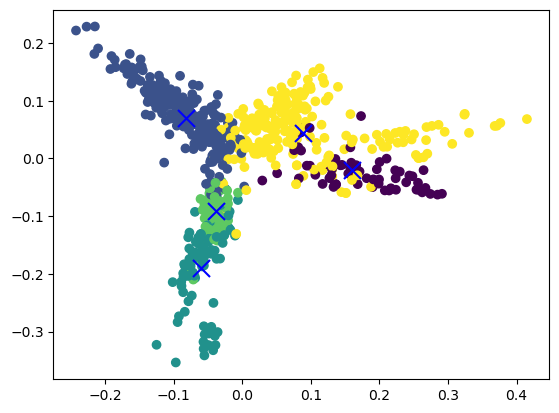

In [12]:
# reduce the features to 2D
pca = PCA(n_components=2, random_state=random_state)
reduced_features = pca.fit_transform(tfidf_matrix.toarray())

# reduce the cluster centers to 2D
reduced_cluster_centers = pca.transform(cls.cluster_centers_)

plt.scatter(reduced_features[:,0], reduced_features[:,1], c=cls.predict(tfidf_matrix))
plt.scatter(reduced_cluster_centers[:, 0], reduced_cluster_centers[:,1], marker='x', s=150, c='b')

7. **Evaluate the quality of the K-Means clustering with the `sklearn` metrics for clustering: `homogeneity_score`, `completeness_score`, `v_measure_score`, `adjusted_rand_score`, `silhouette_score`.**

Evaluation for unsupervised learning algorithms is a bit difficult and requires human judgement, but there are some metrics which you might use. There are two kinds of metrics you can use depending on whether or not you have the labels.

If you have a labelled dataset you can use metrics that give you an idea of how good your clustering model is. For this purpose, you can use the `sklearn.metrics` module, for example, `homogeneity_score` is one of the possible metrics. As per the documentation, the score ranges between 0 and 1, where 1 stands for perfectly homogeneous labeling.

If you do not have labels for your dataset, then you can still evaluate your clustering model with some metrics. One of them is the `silhouette_score`. From the `sklearn`'s documentation: The Silhouette Coefficient is calculated using the mean intra-cluster distance (a) and the mean nearest-cluster distance (b) for each sample. The Silhouette Coefficient for a sample is `(b - a) / max(a,b)`. To clarify, `b` is the distance between a sample and the nearest cluster that the sample is not a part of. The best value is 1 and the worst value is -1. Values near 0 indicate overlapping clusters. Negative values generally indicate that a sample has been assigned to the wrong cluster, as a different cluster is more similar.


In [13]:
print("Homogeneity: %0.3f" % metrics.homogeneity_score(data.target, cls.labels_))
print("Completeness: %0.3f" % metrics.completeness_score(data.target, cls.labels_))
print("V-measure: %0.3f" % metrics.v_measure_score(data.target, cls.labels_))
print("Adjusted Rand-Index: %.3f"
      % metrics.adjusted_rand_score(data.target, cls.labels_))
print("Silhouette Coefficient: %0.3f"
      % metrics.silhouette_score(tfidf_matrix, cls.labels_, sample_size=1000))

Homogeneity: 0.709
Completeness: 0.739
V-measure: 0.724
Adjusted Rand-Index: 0.697
Silhouette Coefficient: 0.015


8. **Apply the K-Means clustering method on a range of 3 to 7 clusters, and calculate the squared loss obtained in each clustering. Apply the Elbow method to find the optimal k. (Tip: use the cls.inertia_ for the squared loss)**

In [14]:
num_clus = [x for x in range(3, 7)]
squared_errors = []
for cluster in num_clus:
    cls = MiniBatchKMeans(n_clusters=cluster, random_state=random_state, n_init = 3)
    cls.fit(tfidf_matrix) # Train Clusters
    squared_errors.append(cls.inertia_) # Appending the squared loss obtained in the list

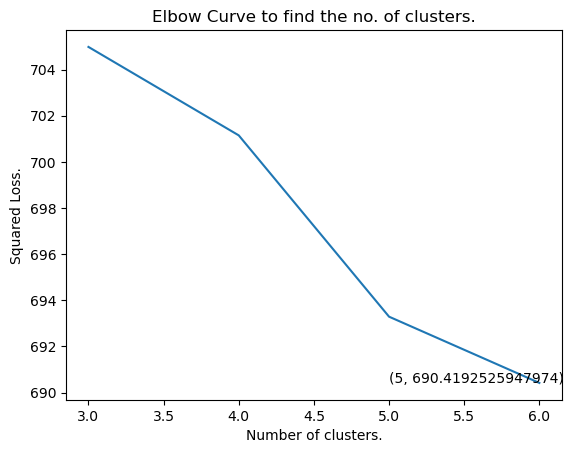

The optimal number of clusters obtained is -  5
The loss for optimal cluster is -  690.4192525947974


In [15]:
# https://www.kaggle.com/karthik3890/text-clustering
# Choosing the best cluster using Elbow Method.
# source credit,few parts of min squred loss info is taken from different parts of the stakoverflow answers.
# this is used to understand to find the optimal clusters in differen way rather than used in BOW, TFIDF

num_clus = [x for x in range(3, 7)]
squared_errors = []
for cluster in num_clus:
    cls = MiniBatchKMeans(n_clusters=cluster, random_state=random_state, n_init = 3)
    cls.fit(tfidf_matrix) # Train Clusters
    squared_errors.append(cls.inertia_) # Appending the squared loss obtained in the list

optimal_clusters = np.argmin(squared_errors) + 2 # As argmin return the index of minimum loss.
plt.plot(num_clus, squared_errors)
plt.title("Elbow Curve to find the no. of clusters.")
plt.xlabel("Number of clusters.")
plt.ylabel("Squared Loss.")
xy = (optimal_clusters, min(squared_errors))
plt.annotate('(%s, %s)' % xy, xy = xy, textcoords='data')
plt.show()

print ("The optimal number of clusters obtained is - ", optimal_clusters)
print ("The loss for optimal cluster is - ", min(squared_errors))

9. **Use the following two news articles as your test data, and predict cluster labels for your new dataset with the best value for K and the K-Means algorithm.**

In [16]:
documents = ['Frank de Boer out as Oranje manager after early Euro 2020 exit Dutch men’s football team coach.',
             'The time has come for Nadal to be selective in the events that he should and should not play. This is where he can start the difficulty. After a rigorous participation of the clay season, Rafael Nadal definitely wants to conserve his energies for as long as possible.']

In [17]:
n_clusters = 5
cls = MiniBatchKMeans(n_clusters=n_clusters, random_state=random_state, n_init = 3)
cls.fit(tfidf_matrix)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.",5
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:'k-means++' : selects initial cluster centroids using sampling based onan empirical probability distribution of the points' contribution to theoverall inertia. This technique speeds up convergence. The algorithmimplemented is ""greedy k-means++"". It differs from the vanilla k-means++by making several trials at each sampling step and choosing the best centroidamong them.'random': choose `n_clusters` observations (rows) at random from datafor the initial centroids.If an array is passed, it should be of shape (n_clusters, n_features)and gives the initial centers.If a callable is passed, it should take arguments X, n_clusters and arandom state and return an initialization.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"max_iter max_iter: int, default=100Maximum number of iterations over the complete dataset beforestopping independently of any early stopping criterion heuristics.",100
,"batch_size batch_size: int, default=1024Size of the mini batches.For faster computations, you can set `batch_size > 256 * number_of_cores`to enable :ref:`parallelism `on all cores... versionchanged:: 1.0 `batch_size` default changed from 100 to 1024.",1024
,"verbose verbose: int, default=0Verbosity mode.",0
,"compute_labels compute_labels: bool, default=TrueCompute label assignment and inertia for the complete datasetonce the minibatch optimization has converged in fit.",True
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization andrandom reassignment. Use an int to make the randomness deterministic.See :term:`Glossary `.",321
,"tol tol: float, default=0.0Control early stopping based on the relative center changes asmeasured by a smoothed, variance-normalized of the mean centersquared position changes. This early stopping heuristics iscloser to the one used for the batch variant of the algorithmsbut induces a slight computational and memory overhead over theinertia heuristic.To disable convergence detection based on normalized centerchange, set tol to 0.0 (default).",0.0
,"max_no_improvement max_no_improvement: int, default=10Control early stopping based on the consecutive number of minibatches that does not yield an improvement on the smoothed inertia.To disable convergence detection based on inertia, setmax_no_improvement to None.",10
,"init_size init_size: int, default=NoneNumber of samples to randomly sample for speeding up theinitialization (sometimes at the expense of accuracy): theonly algorithm is initialized by running a batch KMeans on arandom subset of the data. This needs to be larger than n_clusters.If `None`, the heuristic is `init_size = 3 * batch_size` if`3 * batch_size < n_clusters`, else `init_size = 3 * n_clusters`.",None
,"n_init n_init: 'auto' or int, default=""auto""Number of random initializations that are tried.In contrast to KMeans, the algorithm is only run once, using the best ofthe `n_init` initializations as measured by inertia. Several runs arerecommended for sparse high-dimensional problems (see:ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:3 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'` in version.",3


In [18]:
tfidf_test = tfidf_vectorizer.transform(documents)
tfidf_test.shape

(2, 21604)

In [19]:
print(cls.predict(tfidf_test))

[1 1]


## Hierarchical clustering
10. **Hierarchical clustering is a type of unsupervised machine learning algorithm used to cluster unlabeled data points. Similar to the K-Means clustering, hierarchical clustering groups the data points with similar characteristics together. Apply a hierarchical clustering with the ward linkage on the BBC Sport dataset. Fit the model with 5 clusters and check the predicted labels.**

In [20]:
cls2 = AgglomerativeClustering(n_clusters=5, metric='euclidean', linkage='ward')
cls2 = cls2.fit(tfidf_matrix.toarray())
cls2.labels_

array([4, 4, 2, 2, 2, 4, 0, 0, 2, 2, 0, 1, 2, 2, 2, 2, 2, 2, 2, 4, 1, 2,
       1, 1, 2, 2, 2, 2, 1, 0, 2, 2, 2, 2, 0, 0, 4, 1, 0, 2, 2, 2, 0, 2,
       2, 1, 2, 2, 4, 0, 1, 0, 4, 2, 2, 1, 2, 1, 0, 2, 4, 0, 0, 0, 1, 2,
       2, 0, 0, 2, 1, 4, 2, 2, 0, 1, 2, 2, 0, 4, 4, 1, 2, 1, 2, 1, 2, 1,
       2, 1, 0, 0, 1, 0, 2, 3, 4, 0, 1, 4, 2, 0, 0, 4, 2, 2, 4, 4, 2, 2,
       1, 0, 4, 4, 2, 0, 0, 0, 2, 4, 1, 2, 2, 1, 4, 2, 2, 2, 0, 0, 1, 1,
       4, 4, 2, 1, 2, 2, 0, 0, 2, 3, 2, 0, 2, 2, 2, 1, 2, 0, 0, 2, 2, 0,
       4, 2, 1, 2, 4, 2, 2, 2, 2, 4, 2, 4, 0, 0, 4, 2, 2, 2, 1, 2, 1, 1,
       2, 2, 2, 2, 2, 0, 4, 0, 4, 1, 1, 0, 0, 4, 2, 2, 1, 1, 4, 2, 1, 2,
       2, 0, 4, 2, 0, 2, 4, 4, 1, 0, 1, 2, 1, 0, 0, 0, 0, 2, 4, 3, 2, 2,
       0, 4, 1, 1, 1, 2, 2, 1, 1, 4, 1, 4, 2, 1, 2, 2, 2, 1, 4, 1, 2, 2,
       2, 2, 2, 4, 2, 0, 1, 4, 4, 1, 0, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 0,
       2, 0, 1, 0, 0, 0, 0, 2, 4, 2, 2, 2, 1, 4, 1, 0, 2, 4, 0, 2, 1, 0,
       0, 0, 4, 2, 2, 0, 2, 0, 0, 2, 4, 2, 0, 0, 4,

11. **Plot a dendrogram for your hierarchical clustering model using the function below. To do this, you need to fit the model again without assigning the number of clusters.**

In [21]:
def plot_dendrogram(model, **kwargs):
    # Create linkage matrix and then plot the dendrogram

    # create the counts of samples under each node
    counts = np.zeros(model.children_.shape[0])
    n_samples = len(model.labels_)
    for i, merge in enumerate(model.children_):
        current_count = 0
        for child_idx in merge:
            if child_idx < n_samples:
                current_count += 1  # leaf node
            else:
                current_count += counts[child_idx - n_samples]
        counts[i] = current_count

    linkage_matrix = np.column_stack([model.children_, model.distances_,
                                      counts]).astype(float)

    # Plot the corresponding dendrogram
    dendrogram(linkage_matrix, **kwargs)

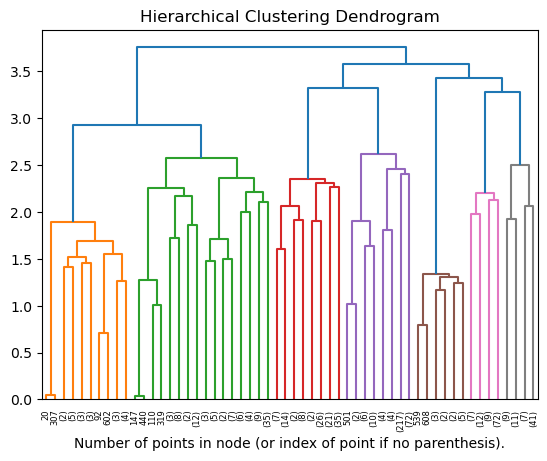

In [22]:
# setting distance_threshold=0 ensures we compute the full tree.
cls2 = AgglomerativeClustering(n_clusters=None, metric='euclidean', linkage='ward', distance_threshold=0)
cls2 = cls2.fit(tfidf_matrix.toarray())

plt.title('Hierarchical Clustering Dendrogram')
# plot the top three levels of the dendrogram
plot_dendrogram(cls2, truncate_mode='level', p=5)
plt.xlabel("Number of points in node (or index of point if no parenthesis).")
plt.show()

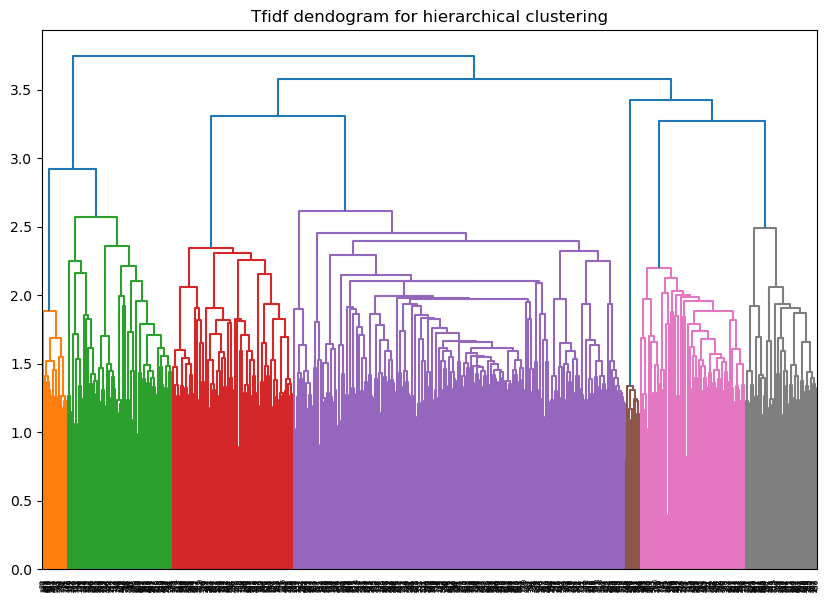

In [23]:
# here is another way of plotting the hc using the scipy library
import scipy.cluster.hierarchy as shc
plt.figure(figsize=(10, 7))
plt.title("Tfidf dendogram for hierarchical clustering")
dend = shc.dendrogram(shc.linkage(tfidf_matrix.toarray(), method='ward'))

## Topic modeling

Topic modeling is another unsupervised method for text mining applications where we want to get an idea of what topics we have in our dataset. A topic is a collection of words that describe the overall theme. For example, in case of news articles, you might think of topics as the categories in the dataset. Just like clustering algorithms, there are some algorithms that need you to specify the number of topics you want to extract from the dataset and some that automatically determine the number of topics. Here, we are going to use the Latent Dirichlet Allocation (LDA) method for topic modeling. You can check sklearn's documentation for more details about LDA from the `sklearn.decomposition` module.

12. **One of the mainly used approaches for topic modeling is Latent Dirichlet Allocation (LDA). The LDA is based upon two general assumptions:**
- Documents exhibit multiple topics
- A topic is a distribution over a fixed vocabulary

**Train a LDA model from the `sklearn` package for topic modeling with 5 components.**


In [24]:
LDA = LatentDirichletAllocation(n_components=5, random_state=321, evaluate_every=10)
LDA.fit(tfidf_matrix)

,"n_components n_components: int, default=10Number of topics... versionchanged:: 0.19 ``n_topics`` was renamed to ``n_components``",5
,"doc_topic_prior doc_topic_prior: float, default=NonePrior of document topic distribution `theta`. If the value is None,defaults to `1 / n_components`.In [1]_, this is called `alpha`.",None
,"topic_word_prior topic_word_prior: float, default=NonePrior of topic word distribution `beta`. If the value is None, defaultsto `1 / n_components`.In [1]_, this is called `eta`.",None
,"learning_method learning_method: {'batch', 'online'}, default='batch'Method used to update `_component`. Only used in :meth:`fit` method.In general, if the data size is large, the online update will be muchfaster than the batch update.Valid options:- 'batch': Batch variational Bayes method. Use all training data in each EM update. Old `components_` will be overwritten in each iteration.- 'online': Online variational Bayes method. In each EM update, use mini-batch of training data to update the ``components_`` variable incrementally. The learning rate is controlled by the ``learning_decay`` and the ``learning_offset`` parameters... versionchanged:: 0.20 The default learning method is now ``""batch""``.",'batch'
,"learning_decay learning_decay: float, default=0.7It is a parameter that control learning rate in the online learningmethod. The value should be set between (0.5, 1.0] to guaranteeasymptotic convergence. When the value is 0.0 and batch_size is``n_samples``, the update method is same as batch learning. In theliterature, this is called kappa.",0.7
,"learning_offset learning_offset: float, default=10.0A (positive) parameter that downweights early iterations in onlinelearning. It should be greater than 1.0. In the literature, this iscalled tau_0.",10.0
,"max_iter max_iter: int, default=10The maximum number of passes over the training data (aka epochs).It only impacts the behavior in the :meth:`fit` method, and not the:meth:`partial_fit` method.",10
,"batch_size batch_size: int, default=128Number of documents to use in each EM iteration. Only used in onlinelearning.",128
,"evaluate_every evaluate_every: int, default=-1How often to evaluate perplexity. Only used in `fit` method.set it to 0 or negative number to not evaluate perplexity intraining at all. Evaluating perplexity can help you check convergencein training process, but it will also increase total training time.Evaluating perplexity in every iteration might increase training timeup to two-fold.",10
,"total_samples total_samples: int, default=1e6Total number of documents. Only used in the :meth:`partial_fit` method.",1000000.0
,"perp_tol perp_tol: float, default=1e-1Perplexity tolerance. Only used when ``evaluate_every`` is greater than 0.",0.1


We used LDA to create topics along with the probability distribution for each word in our vocabulary for each topic. The parameter n_components specifies the number of categories, or topics, that we want our text to be divided into.

13. **Print the 10 words with highest probabilities for all the five topics.**

In [25]:
for i,topic in enumerate(LDA.components_):
    print(f'Top 10 words for topic #{i}:')
    print([tfidf_vectorizer.get_feature_names_out()[i] for i in topic.argsort()[-10:]])
    print('\n')

Top 10 words for topic #0:
['play', 'cup', 'players', 'team', 'win', 'world', 'year', 'game', 'england', 'said']


Top 10 words for topic #1:
['maurice', 'holmes', 'capriati', 'mauresmo', 'isinbayeva', 'sharapova', 'greene', 'lewis francis', 'francis', 'mirza']


Top 10 words for topic #2:
['gregory lamboley', 'imanol', 'half replacement', 'valbon', 'harinordoquy', 'stade', 'bortolami', 'bourgoin', 'toulousain', 'stade toulousain']


Top 10 words for topic #3:
['tribunal', 'charges', 'balco', 'conte', 'drugs', 'doping', 'thanou', 'greek', 'iaaf', 'kenteris']


Top 10 words for topic #4:
['equal prize', 'rod', 'aus', 'ind', 'pattaya', 'prize money', 'kafer', 'martinez', 'umaga', 'hingis']




You can also use the following function for this purpose:

In [26]:
def display_topics(model, feature_names, no_top_words):
    topic_dict = {}
    for topic_idx, topic in enumerate(model.components_):
        topic_dict["Topic %d words" % (topic_idx)]= ['{}'.format(feature_names[i])
                        for i in topic.argsort()[:-no_top_words - 1:-1]]
        topic_dict["Topic %d weights" % (topic_idx)]= ['{:.1f}'.format(topic[i])
                        for i in topic.argsort()[:-no_top_words - 1:-1]]
    return pd.DataFrame(topic_dict)

In [27]:
#no_top_words = 10
display_topics(LDA, tfidf_vectorizer.get_feature_names_out(), no_top_words=4)

,Topic 0 words,Topic 0 weights,Topic 1 words,Topic 1 weights,Topic 2 words,Topic 2 weights,Topic 3 words,Topic 3 weights,Topic 4 words,Topic 4 weights
0,said,21.1,mirza,2.2,stade toulousain,1.0,kenteris,3.5,hingis,1.0
1,england,18.2,francis,2.0,toulousain,1.0,iaaf,3.1,umaga,1.0
2,game,13.8,lewis francis,2.0,bourgoin,0.6,greek,3.1,martinez,0.9
3,year,13.6,greene,1.7,bortolami,0.6,thanou,3.1,kafer,0.8


14. **Transform the learned topics into your data. Check the shape of the output. What can be the use of this output?**

In [28]:
topic_values = LDA.transform(tfidf_matrix)
topic_values.shape

(737, 5)

In [29]:
topic_values

array([[0.95297704, 0.01175449, 0.01175873, 0.01175444, 0.01175529],
       [0.94455696, 0.01385469, 0.01387983, 0.0138542 , 0.01385432],
       [0.94949035, 0.01264149, 0.01261802, 0.01263226, 0.01261788],
       ...,
       [0.92571628, 0.01857336, 0.01856985, 0.01857083, 0.01856967],
       [0.4823713 , 0.48677254, 0.01028672, 0.01028405, 0.0102854 ],
       [0.363303  , 0.01191515, 0.60094594, 0.01191983, 0.01191608]])

15. **Use the `score` function for LDA to calculate the log likelihood for your data. Compare two LDA models with 5 and 10 topics.**

In [30]:
LDA10 = LatentDirichletAllocation(n_components=10, random_state=321, evaluate_every=10)
LDA10.fit(tfidf_matrix)
print("The log likelihood for the LDA model with 5 topics:", LDA.score(tfidf_matrix))
print("The log likelihood for the LDA model with 10 topics:", LDA10.score(tfidf_matrix))

The log likelihood for the LDA model with 5 topics: -91498.09007139162
The log likelihood for the LDA model with 10 topics: -106388.8618153607


Many procedures use the log of the likelihood, rather than the likelihood itself, because it is easier to work with. The log likelihood (i.e., the log of the likelihood) will always be negative, with higher values (closer to zero) indicating a better fitting model. Here this belongs to the model with 5 topics.

In [35]:
test_topic_values = LDA.transform(tfidf_test)

In [36]:
test_dominant_topics = test_topic_values.argmax(axis=1)

In [37]:
print(test_dominant_topics)

[0 0]
